# JAX DLGN With `take_datasets`

This notebook rewrites the DLGN training flow into a DLCA-style JAX setup while keeping the older difflogic dataset conventions:

- JAX logic-gate layers with soft, gumbel, or dirichlet gate decoding
- Flax-style immutable train state
- Optax optimizer updates
- difflogic-style `GroupSum` class head
- dataset names and loading branches aligned with the earlier PyTorch notebook

The default demo uses a tiny synthetic XOR dataset so the notebook is runnable even when the external datasets are not downloaded. To switch to the repo datasets, change `config['dataset']` in the training cell.


In [1]:
from __future__ import annotations

import os

from functools import partial
from pathlib import Path
from typing import Literal
import importlib
import itertools
import math

from collections import namedtuple
from datetime import datetime
from functools import partial
import io
import itertools
from base64 import b64decode
from typing import List, Optional, Sequence, Tuple

from einops import rearrange
import flax.linen as nn
import flax.linen as nn
from IPython.display import HTML, Image, clear_output
import jax
print(jax.__version__)
from jax import grad
from jax.lax import conv_general_dilated_patches
import jax.numpy as jnp
import jax.random as random
from jax.tree_util import tree_leaves, tree_map
from matplotlib import colors
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import matplotlib.style as style
from matplotlib.ticker import MaxNLocator
import numpy as np
import optax
import PIL
import PIL.Image, PIL.ImageDraw, PIL.ImageFont, PIL.ImageOps
import requests


os.environ['FFMPEG_BINARY'] = 'ffmpeg'

import flax
import jax
import jax.numpy as jnp
import numpy as np
import optax

jax.clear_caches()
print('jax', jax.__version__)
print('flax', flax.__version__)
print('optax', optax.__version__)


0.9.0.1
jax 0.9.0.1
flax 0.12.4
optax 0.2.6


In [2]:
PASS_THROUGH_GATE = 3
DEFAULT_PASS_VALUE = 10.0
NUMBER_OF_GATES = 16
LIGHT_TRUTH_TABLE_SIZE = 4
TRUTH_TABLE_BIT_WEIGHTS = jnp.asarray([8, 4, 2, 1], dtype=jnp.int32)

"""
Fire rate for asynchronicity.

60% of cells will perform the update,
40% will have the update masked.
"""
FIRE_RATE = 0.6

TARGET_EMOJI = "🦎"
TARGET_SIZE_EMOJI = 20
TARGET_SIZE_G = 16
TARGET_SIZE_ASYNC = 14
TARGET_SIZE = 16


GATE_NAMES = [
    'FALSE',
    'AND',
    'A_AND_NOT_B',
    'A',
    'NOT_A_AND_B',
    'B',
    'XOR',
    'OR',
    'NOR',
    'XNOR',
    'NOT_B',
    'A_OR_NOT_B',
    'NOT_A',
    'NOT_A_OR_B',
    'NAND',
    'TRUE',
]

LIGHT_TRUTH_TABLE_NAMES = ['00', '01', '10', '11']

ConnectionType = Literal['random', 'unique']
LogicFamily = Literal['full', 'light']
WirePair = tuple[jax.Array, jax.Array]
UpdatePerceivePair = tuple[jax.Array, jax.Array]


def get_unique_connections(in_dim: int, out_dim: int, key: jax.Array) -> WirePair:
    if out_dim * 2 < in_dim:
        raise ValueError(
            'unique connections require out_dim * 2 >= in_dim: '
            f'{out_dim=} {in_dim=}'
        )

    x = jnp.arange(in_dim)
    a = x[::2]
    b = x[1::2]
    m = min(a.shape[0], b.shape[0])
    a = a[:m]
    b = b[:m]

    if a.shape[0] < out_dim:
        a_ = x[1::2]
        b_ = x[2::2]
        m = min(a_.shape[0], b_.shape[0])
        a = jnp.concatenate([a, a_[:m]])
        b = jnp.concatenate([b, b_[:m]])

    offset = 2
    while out_dim > a.shape[0] and offset < in_dim:
        a = jnp.concatenate([a, x[:-offset]])
        b = jnp.concatenate([b, x[offset:]])
        offset += 1

    if a.shape[0] < out_dim:
        raise ValueError(
            f'Could not generate enough unique connections: {a.shape[0]} < {out_dim}'
        )

    a = a[:out_dim]
    b = b[:out_dim]
    perm = jax.random.permutation(key, out_dim)
    return a[perm], b[perm]


def logic_family_of_logits(logits: jax.Array) -> LogicFamily:
    if logits.shape[-1] == LIGHT_TRUTH_TABLE_SIZE:
        return 'light'
    if logits.shape[-1] == NUMBER_OF_GATES:
        return 'full'
    raise ValueError(f'Unsupported gate parameter size: {logits.shape[-1]}')


def truth_table_bits_to_gate_id(bits: jax.Array) -> jax.Array:
    bits = bits.astype(jnp.int32)
    return jnp.sum(bits * TRUTH_TABLE_BIT_WEIGHTS, axis=-1).astype(jnp.int32)


def hard_gate_ids_from_logits(logits: jax.Array) -> jax.Array:
    logic_family = logic_family_of_logits(logits)
    if logic_family == 'light':
        return truth_table_bits_to_gate_id(decode_light_hard(logits))
    return jnp.argmax(logits, axis=-1).astype(jnp.int32)


def bin_op_all_combinations(a: jax.Array, b: jax.Array) -> jax.Array:
    return jnp.stack(
        [
            jnp.zeros_like(a),
            a * b,
            a - a * b,
            a,
            b - a * b,
            b,
            a + b - 2 * a * b,
            a + b - a * b,
            1 - (a + b - a * b),
            1 - (a + b - 2 * a * b),
            1 - b,
            1 - b + a * b,
            1 - a,
            1 - a + a * b,
            1 - a * b,
            jnp.ones_like(a),
        ],
        axis=-1,
    )


def bin_op_s(a: jax.Array, b: jax.Array, gate_weights: jax.Array) -> jax.Array:
    return jnp.sum(bin_op_all_combinations(a, b) * gate_weights[None, ...], axis=-1)

# def bin_op_s(a: jax.Array, b: jax.Array, gate_weights: jax.Array) -> jax.Array:
#     return jnp.sum(bin_op_all_combinations(a, b) * gate_weights, axis=-1)


def light_truth_table_basis(a: jax.Array, b: jax.Array) -> jax.Array:
    return jnp.stack(
        [
            (1.0 - a) * (1.0 - b),
            (1.0 - a) * b,
            a * (1.0 - b),
            a * b,
        ],
        axis=-1,
    )


# def bin_op_light(a: jax.Array, b: jax.Array, truth_table_weights: jax.Array) -> jax.Array:
#     return jnp.sum(light_truth_table_basis(a, b) * truth_table_weights, axis=-1)

def bin_op_light(a: jax.Array, b: jax.Array, truth_table_weights: jax.Array) -> jax.Array:
    return jnp.sum(light_truth_table_basis(a, b) * truth_table_weights[None, ...], axis=-1)


def decode_soft(logits: jax.Array) -> jax.Array:
    return jax.nn.softmax(logits, axis=-1)


def decode_gumbel_soft(
    logits: jax.Array,
    key: jax.Array,
    temperature: float = 1.0,
) -> jax.Array:
    temperature = jnp.maximum(temperature, 1e-6)
    noise = jax.random.gumbel(key, logits.shape)
    return jax.nn.softmax((logits + noise) / temperature, axis=-1)


def decode_gumbel_st(
    logits: jax.Array,
    key: jax.Array,
    temperature: float = 1.0,
) -> jax.Array:
    # PyTorch parity for full-gate gumbel: gumbel_softmax(..., hard=True).
    y_soft = decode_gumbel_soft(logits, key, temperature)
    y_hard = jax.nn.one_hot(jnp.argmax(y_soft, axis=-1), logits.shape[-1], dtype=y_soft.dtype)
    return y_soft + jax.lax.stop_gradient(y_hard - y_soft)


def decode_dirichlet_sample(
    logits: jax.Array,
    key: jax.Array,
    eps: float = 1e-6,
) -> jax.Array:
    # PyTorch parity for full-gate dirichlet: alpha = softplus(weights), then sample.
    alpha = jax.nn.softplus(logits) + eps
    return jax.random.dirichlet(key, alpha)

def decode_full_hard(logits: jax.Array) -> jax.Array:
    return jax.nn.one_hot(jnp.argmax(logits, axis=-1), logits.shape[-1])


def decode_light_soft(logits: jax.Array) -> jax.Array:
    return jax.nn.sigmoid(logits)


def decode_light_st(logits: jax.Array) -> jax.Array:
    truth_table_soft = decode_light_soft(logits)
    truth_table_hard = (truth_table_soft >= 0.5).astype(truth_table_soft.dtype)
    return truth_table_soft + jax.lax.stop_gradient(truth_table_hard - truth_table_soft)


def decode_light_hard(logits: jax.Array) -> jax.Array:
    return (decode_light_soft(logits) >= 0.5).astype(logits.dtype)


def init_full_gates(
    n: int,
    num_gates: int = NUMBER_OF_GATES,
    pass_through_gate: int = PASS_THROUGH_GATE,
    default_pass_value: float = DEFAULT_PASS_VALUE,
) -> jax.Array:
    gates = jnp.zeros((n, num_gates))
    return gates.at[:, pass_through_gate].set(default_pass_value)


def init_light_gates(
    n: int,
    default_pass_value: float = DEFAULT_PASS_VALUE,
) -> jax.Array:
    gates = jnp.full((n, LIGHT_TRUTH_TABLE_SIZE), -default_pass_value)
    return gates.at[:, 2:].set(default_pass_value)


def init_gate_layer(
    key: jax.Array,
    in_dim: int,
    out_dim: int,
    connection_type: ConnectionType,
    logic_family: LogicFamily,
) -> tuple[jax.Array, WirePair]:
    if connection_type == 'random':
        key1, key2 = jax.random.split(key)
        c = jax.random.permutation(key2, 2 * out_dim) % in_dim
        c = jax.random.permutation(key1, in_dim)[c]
        c = c.reshape(2, out_dim)
        wires = (c[0], c[1])
    elif connection_type == 'unique':
        wires = get_unique_connections(in_dim, out_dim, key)
    else:
        raise ValueError(f'Unknown connection type: {connection_type!r}')

    if logic_family == 'full':
        gate_params = init_full_gates(out_dim)
    elif logic_family == 'light':
        gate_params = init_light_gates(out_dim)
    else:
        raise ValueError(f'Unknown logic family: {logic_family!r}')

    return gate_params, wires


def build_layer_sizes(input_dim: int, num_neurons: int, num_layers: int) -> list[int]:
    if num_layers < 1:
        raise ValueError('num_layers must be at least 1')
    return [input_dim] + [num_neurons] * num_layers


def init_logic_gate_network(
    input_dim: int,
    num_neurons: int,
    num_layers: int,
    connections: ConnectionType,
    key: jax.Array,
    logic_family: LogicFamily,
) -> tuple[list[jax.Array], list[WirePair]]:
    layer_sizes = build_layer_sizes(input_dim, num_neurons, num_layers)
    params = []
    wires = []

    for in_dim, out_dim in zip(layer_sizes[:-1], layer_sizes[1:]):
        key, subkey = jax.random.split(key)
        gate_logits, gate_wires = init_gate_layer(
            subkey,
            int(in_dim),
            int(out_dim),
            connections,
            logic_family,
        )
        params.append(gate_logits)
        wires.append(gate_wires)

    return params, wires


def decode_training_gates(
    logits: jax.Array,
    key: jax.Array,
    architecture: str,
    gumb_tau: float,
    dirichlet_concentration: float,
    logic_family: LogicFamily,
) -> jax.Array:
    del dirichlet_concentration

    if logic_family == 'full':
        if architecture == 'softmax':
            return decode_soft(logits)
        if architecture == 'gumbel':
            return decode_gumbel_st(logits, key, gumb_tau)
        if architecture == 'dirichlet':
            return decode_dirichlet_sample(logits, key)
        raise ValueError(f'Unknown full-DLGN architecture: {architecture!r}')

    if logic_family == 'light':
        if architecture in ('light_sigmoid', 'sigmoid'):
            return decode_light_soft(logits)
        if architecture in ('light_st', 'light_sigmoid_st', 'sigmoid_st'):
            return decode_light_st(logits)
        raise ValueError(f'Unknown light-DLGN architecture: {architecture!r}')

    raise ValueError(f'Unknown logic family: {logic_family!r}')

def decode_hard(logits: jax.Array, logic_family: LogicFamily) -> jax.Array:
    if logic_family == 'full':
        return decode_full_hard(logits)
    if logic_family == 'light':
        return decode_light_hard(logits)
    raise ValueError(f'Unknown logic family: {logic_family!r}')


def run_layer(
    logits: jax.Array,
    wires: WirePair,
    x: jax.Array,
    training: bool,
    key: jax.Array,
    architecture: str,
    gumb_tau: float,
    dirichlet_concentration: float,
    logic_family: LogicFamily,
) -> jax.Array:
    a = x[..., wires[0]]
    b = x[..., wires[1]]
    gate_weights = (
        decode_training_gates(
            logits,
            key,
            architecture,
            gumb_tau,
            dirichlet_concentration,
            logic_family,
        )
        if training
        else decode_hard(logits, logic_family)
    )

    if logic_family == 'full':
        return bin_op_s(a, b, gate_weights)
    if logic_family == 'light':
        return bin_op_light(a, b, gate_weights)
    raise ValueError(f'Unknown logic family: {logic_family}')


def run_logic_gate_network(
    params: list[jax.Array],
    wires: list[WirePair],
    x: jax.Array,
    training: bool,
    key: jax.Array,
    architecture: str,
    gumb_tau: float,
    dirichlet_concentration: float,
    logic_family: LogicFamily,
) -> jax.Array:
    layer_keys = jax.random.split(key, len(params))
    for logits, layer_wires, layer_key in zip(params, wires, layer_keys):
        x = run_layer(
            logits,
            layer_wires,
            x,
            training,
            layer_key,
            architecture,
            gumb_tau,
            dirichlet_concentration,
            logic_family,
        )
    return x


def group_sum_head(x: jax.Array, class_count: int, sum_tau: float) -> jax.Array:
    if x.shape[-1] % class_count != 0:
        raise ValueError(
            'num_neurons must be divisible by class_count for GroupSum: '
            f'{x.shape[-1]=} {class_count=}'
        )
    group_size = x.shape[-1] // class_count
    x = x.reshape(x.shape[0], class_count, group_size)
    return x.sum(axis=-1) / jnp.maximum(sum_tau, 1e-6)


def forward_logits(
    params: list[jax.Array],
    wires: list[WirePair],
    x: jax.Array,
    training: bool,
    key: jax.Array,
    architecture: str,
    gumb_tau: float,
    dirichlet_concentration: float,
    class_count: int,
    sum_tau: float,
    logic_family: LogicFamily,
) -> jax.Array:
    features = run_logic_gate_network(
        params,
        wires,
        x,
        training,
        key,
        architecture,
        gumb_tau,
        dirichlet_concentration,
        logic_family,
    )
    return group_sum_head(features, class_count, sum_tau)


In [3]:
# =============================================================================
# 1) Visualization utilities (NOT part of the model; safe to separate/delete)
# =============================================================================

def zoom(img, scale=4):
  """
  Nearest-neighbor zoom for visualization.
  - Repeats rows and columns `scale` times using NumPy.
  - Useful for making small grids readable as images.
  """
  img = np.repeat(img, scale, 0)
  img = np.repeat(img, scale, 1)
  return img


def load_byte(byte, max_size=TARGET_SIZE):
  """
  Load an RGBA image from raw bytes and normalize to float32 [0,1].
  - Uses PIL to decode and thumbnail.
  - Premultiplies RGB by Alpha (common for compositing).
    i.e. RGB <- RGB * A so transparent pixels don’t “bleed” color.
  """
  img = PIL.Image.open(io.BytesIO(byte))
  img.thumbnail((max_size, max_size), PIL.Image.LANCZOS)
  img = np.float32(img) / 255.0
  img[..., :3] *= img[..., 3:]  # premultiply RGB by Alpha
  return img


def visualize(frames, namefile, size, negate=1):
  """
  Save a list/array of frames as an animated GIF.
  - frames: sequence of 2D arrays (H,W) or (H,W,1)
  - negate: if True, maps x -> 1-x (helpful for binary images)
  """
  fig, ax = plt.subplots(figsize=(size, size))
  ax.set_xticks([])
  ax.set_yticks([])

  def animate(frame):
    ax.clear()
    ax.set_xticks([])
    ax.set_yticks([])
    if negate:
      frame = 1 - frame
    return [ax.imshow(frame, cmap='binary')]

  anim = animation.FuncAnimation(fig, animate, frames=frames, interval=200, blit=True)
  writer = animation.PillowWriter(fps=2)
  anim.save(namefile, writer=writer)
  plt.close()


def plot_show(img, negate=1):
  """
  Convenience plot for a single frame.
  - negate to invert background/foreground for readability.
  """
  if negate:
    img = 1 - img
  fig, ax = plt.subplots(1, 1, figsize=(5, 5))
  ax.imshow(img, cmap='binary')
  ax.axis('off')
  plt.tight_layout()
  plt.show()


def plot_hist_gates(net, save_path=None, title='Distribution of Gates (Sorted)'):
  """
  Plot histogram of gate types used in a network after hard decoding.
  - net: typically an integer array of gate IDs (0..15)
  - Uses np.bincount to count gate usage.
  - Sorted barh plot so rare/common gates are easy to see.

  Note: this is *analysis tooling*, not needed for training/inference.
  """
  gate_types = [
      'FALSE',
      'AND',
      'A AND (NOT B)',
      'A',
      '(NOT A) AND B',
      'B',
      'XOR',
      'OR',
      'NOR',
      'XNOR',
      'NOT B',
      'A OR (NOT B)',
      'NOT A',
      '(NOT A) OR B',
      'NAND',
      'TRUE',
  ]

  gate_counts = np.bincount(net, minlength=len(gate_types))
  sorted_indices = np.argsort(gate_counts)
  sorted_counts = gate_counts[sorted_indices]
  sorted_gate_types = [gate_types[i] for i in sorted_indices]

  fig, ax = plt.subplots(figsize=(12, 6), dpi=100)
  ax.barh(sorted_gate_types, sorted_counts, alpha=0.7, edgecolor='white', linewidth=1)

  ax.set_xlabel('#Gates', fontsize=12, fontweight='bold')
  ax.set_ylabel('Type of gate', fontsize=12, fontweight='bold')
  ax.set_title(title, fontsize=14, fontweight='bold', pad=20)

  ax.grid(True, linestyle='--', alpha=0.7, axis='x')
  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)
  ax.xaxis.set_major_locator(MaxNLocator(integer=True))

  plt.tight_layout()
  if save_path:
    with open(save_path, 'wb') as f:
      plt.savefig(f, format='svg')
  plt.show()


def plot_training_progress(loss_train, loss_test, compute_every, save_path=None):
  """
  Plot training loss curves.
  - loss_train: recorded often (every step)
  - loss_test: recorded more sparsely (every compute_every steps)
  - Designed for showing “soft gate loss” vs “hard decoded loss”.
  """
  fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
  ax.grid(True, linestyle='--', alpha=0.7)

  ax.plot(loss_train, linewidth=2, label='Soft Gates Loss', alpha=0.9)

  ax.plot(
      np.arange(0, len(loss_train), compute_every),
      loss_test,
      linestyle='--',
      linewidth=2,
      label='Hard Gates Loss',
      alpha=0.9,
  )

  ax.set_xlabel('Training Steps', fontsize=12, fontweight='bold')
  ax.set_ylabel('Loss Value', fontsize=12, fontweight='bold')
  ax.set_title('Training Progress - Soft vs Hard Gates', fontsize=14, fontweight='bold', pad=20)

  ax.legend(loc='upper right')
  plt.tight_layout()

  if save_path:
    with open(save_path, 'wb') as f:
      plt.savefig(f, format='svg')
  plt.show()

In [4]:
import jax
import jax.numpy as jnp
from einops import rearrange
from typing import Callable

from collections import namedtuple
import jax
import jax.numpy as jnp
import optax
from einops import rearrange

# TrainState = namedtuple('TrainState', 'params opt_state key apply_fn')
TrainState = namedtuple('TrainState', 'params opt_state key')

NUMBER_OF_GATES = 16
LIGHT_TRUTH_TABLE_SIZE = 4

WirePair = tuple[jax.Array, jax.Array]


def get_moore_connections(key: jax.Array) -> WirePair:
    neighbors = jnp.array([0, 1, 2, 3, 5, 6, 7, 8])
    center = jnp.full_like(neighbors, 4)
    perm = jax.random.permutation(key, neighbors.shape[0])
    return neighbors[perm], center[perm]


def init_gate_layer_dlca(
    key: jax.Array,
    in_dim: int,
    out_dim: int,
    connection_type: str,
    logic_family: str,
) -> tuple[jax.Array, WirePair]:
    if connection_type == "random":
        key1, key2 = jax.random.split(key)
        c = jax.random.permutation(key2, 2 * out_dim) % in_dim
        c = jax.random.permutation(key1, in_dim)[c]
        c = c.reshape(2, out_dim)
        wires = (c[0], c[1])

    elif connection_type == "unique":
        wires = get_unique_connections(in_dim, out_dim, key)

    elif connection_type == "first_kernel":
        wires = get_moore_connections(key)

    else:
        raise ValueError(f"Unknown connection type: {connection_type!r}")

    if logic_family == "full":
        gate_params = init_full_gates(out_dim)
    elif logic_family == "light":
        gate_params = init_light_gates(out_dim)
    else:
        raise ValueError(f"Unknown logic family: {logic_family!r}")

    return gate_params, wires


def make_decoders(
    logic_family: str,
    architecture: str,
    gumb_tau: float,
) -> tuple[Callable, Callable]:
    if logic_family == "full":
        if architecture == "softmax":
            train_decode = lambda logits, key: decode_soft(logits)
        elif architecture == "gumbel":
            train_decode = lambda logits, key: decode_gumbel_st(logits, key, gumb_tau)
        elif architecture == "dirichlet":
            train_decode = lambda logits, key: decode_dirichlet_sample(logits, key)
        else:
            raise ValueError(f"Unknown full architecture: {architecture!r}")

        eval_decode = lambda logits, key: decode_full_hard(logits)

    elif logic_family == "light":
        if architecture in ("light_sigmoid", "sigmoid"):
            train_decode = lambda logits, key: decode_light_soft(logits)
        elif architecture in ("light_st", "light_sigmoid_st", "sigmoid_st"):
            train_decode = lambda logits, key: decode_light_st(logits)
        else:
            raise ValueError(f"Unknown light architecture: {architecture!r}")

        eval_decode = lambda logits, key: decode_light_hard(logits)

    else:
        raise ValueError(f"Unknown logic family: {logic_family!r}")

    return train_decode, eval_decode


def make_bin_op(logic_family: str):
    if logic_family == "full":
        return bin_op_s
    elif logic_family == "light":
        return bin_op_light
    else:
        raise ValueError(f"Unknown logic family: {logic_family!r}")

        
def init_update_network(hyperparams: dict, key: jax.Array) -> tuple[list[jax.Array], list[WirePair]]:
    logic_family = hyperparams["logic_family"]
    update_layers = hyperparams["update"]["layers"]
    connection_type = hyperparams["update"]["connections"]

    params = []
    wires = []

    for i, (in_dim, out_dim) in enumerate(zip(update_layers[:-1], update_layers[1:])):
        key, subkey = jax.random.split(key)
        gate_logits, gate_wires = init_gate_layer_dlca(
            subkey,
            int(in_dim),
            int(out_dim),
            connection_type[i],
            logic_family,
        )
        params.append(gate_logits)
        wires.append(gate_wires)

    return params, wires


def init_perceive_network(hyperparams: dict, key: jax.Array) -> tuple[list[jax.Array], list[WirePair]]:
    logic_family = hyperparams["logic_family"]
    perceive_layers = hyperparams["perceive"]["layers"]
    n_kernels = int(hyperparams["perceive"]["n_kernels"])
    connection_types = hyperparams["perceive"]["connections"]

    gate_width = NUMBER_OF_GATES if logic_family == "full" else LIGHT_TRUTH_TABLE_SIZE

    params = []
    wires = []

    for i, (in_dim, out_dim) in enumerate(zip(perceive_layers[:-1], perceive_layers[1:])):
        key, subkey = jax.random.split(key)
        gate_logits, gate_wires = init_gate_layer_dlca(
            subkey,
            int(in_dim),
            int(out_dim),
            connection_types[i],
            logic_family,
        )

        # Shared wiring across kernels, separate logits per kernel.
        layer_params = jnp.repeat(gate_logits[None, :, :], n_kernels, axis=0)
        layer_params = layer_params.reshape(n_kernels, int(out_dim), gate_width)

        params.append(layer_params)
        wires.append(gate_wires)

    return params, wires


def make_dlca_fns(hyperparams: dict):
    logic_family = hyperparams["logic_family"]
    architecture = hyperparams["architecture"]
    gumb_tau = hyperparams.get("gumb_tau", 1.0)

    train_decode, eval_decode = make_decoders(
        logic_family=logic_family,
        architecture=architecture,
        gumb_tau=gumb_tau,
    )
    bin_op = make_bin_op(logic_family)

    optimizer = optax.chain(
        optax.clip(hyperparams["clip_value"]),
        optax.adamw(
            learning_rate=hyperparams["learning_rate"],
            b1=0.9,
            b2=0.99,
            weight_decay=hyperparams["weight_decay"],
        ),
    )

    def init_fn(hyperparams):
        
        expected_first_update = (
            hyperparams["channels"] *
            hyperparams["perceive"]["layers"][-1] *
            hyperparams["perceive"]["n_kernels"]
            + hyperparams["channels"]
        )
        actual_first_update = int(hyperparams["update"]["layers"][0])

        if expected_first_update != actual_first_update:
            raise ValueError(
                f"update input mismatch: got {actual_first_update}, expected {expected_first_update}"
            )
        
        key = jax.random.PRNGKey(hyperparams['seed'])
        
        key, update_key = jax.random.split(key)
        update_params, update_wires = init_update_network(hyperparams, update_key)

        key, perceive_key = jax.random.split(key)
        perceive_params, perceive_wires = init_perceive_network(hyperparams, perceive_key)

        params = {
            "update": update_params,
            "perceive": perceive_params,
        }
        wires = {
            "update": update_wires,
            "perceive": perceive_wires,
        }

        opt_state = optimizer.init(params)

        return TrainState(params, opt_state, key), wires

    def run_layer_dlca(logits, wires, x, training, key):
        a = x[..., wires[0]]
        b = x[..., wires[1]]

        gate_weights = jax.lax.cond(
            training,
            lambda l: train_decode(l, key),
            lambda l: eval_decode(l, key),
            logits,
        )
        out = bin_op(a, b, gate_weights)
        
        return out

    def run_update(params, wires, x, training, key):
        layer_keys = jax.random.split(key, len(params))
        for logits, layer_wires, layer_key in zip(params, wires, layer_keys):
            x = run_layer_dlca(logits, layer_wires, x, training, layer_key)
        return x

    def run_perceive(params, wires, x, training, key):
        x_prev = x
        x = x.T
        x = jnp.repeat(x[None, ...], params[0].shape[0], axis=0)

        layer_keys = jax.random.split(key, len(params))

        for layer_params, layer_wires, layer_key in zip(params, wires, layer_keys):
            kernel_keys = jax.random.split(layer_key, layer_params.shape[0])

            run_layer_map = jax.vmap(
                lambda logits, kernel_x, kernel_key: run_layer_dlca(
                    logits, layer_wires, kernel_x, training, kernel_key
                ),
                in_axes=(0, 0, 0),
            )

            x = run_layer_map(layer_params, x, kernel_keys)

        x = rearrange(x, "k c s -> (c s k)")
        return jnp.concatenate([x_prev[4, :], x], axis=-1)

    def apply_fn(train_state: TrainState, wires, x, training):
        key, perceive_key, update_key, next_key = jax.random.split(train_state.key, 4)

        x = run_perceive(
            train_state.params["perceive"],
            wires["perceive"],
            x,
            training,
            perceive_key,
        )
        x = run_update(
            train_state.params["update"],
            wires["update"],
            x,
            training,
            update_key,
        )

        next_state = TrainState(
            params=train_state.params,
            opt_state=train_state.opt_state,
            key=next_key,
        )
        return x, next_state

    return init_fn, apply_fn, optimizer

In [5]:
#TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST 
hyperparams = {'perceive': {}, 'update': {}}
hyperparams['seed'] = 23
hyperparams['lr'] = 0.06
hyperparams['batch_size'] = 1
hyperparams['num_epochs'] = 3000
hyperparams['num_steps'] = 15
hyperparams['channels'] = 16
hyperparams['periodic'] = 0
hyperparams['perceive']['n_kernels'] = 4
hyperparams['perceive']['layers'] = [9, 8, 4, 2, 1]
hyperparams['perceive']['connections'] = ['first_kernel','unique', 'unique', 'unique',]
init = (hyperparams['perceive']['n_kernels'] * hyperparams['channels'] * hyperparams['perceive']['layers'][-1] + hyperparams['channels'])
hyperparams['update']['layers'] = ([init]+ [128] * 10 + [64, 32, 16])
hyperparams['update']['connections'] = ['unique'] * len(hyperparams['update']['layers'])
hyperparams['async_training'] = False
hyperparams['training'] = False
hyperparams['periodic'] = False

hyperparams.update({
    'dataset': 'cifar-10-3-thresholds',
    # 'seed': 0,
    'channels': 16,
    # 'batch_size': 128,
    # 'valid_set_size': 0.1,
    # 'num_workers': 0,
    # 'num_steps': 1200,
    # 'eval_every': 100,
    'learning_rate': 0.03,
    'weight_decay': 1e-4,
    'clip_value': 100.0,
    # 'connections': 'random',
    'logic_family': 'light',  # 'full' or 'light'
    'architecture': 'light_st',  # full: plain softmax / gumbel ST / dirichlet(softplus(logits)); light: 'light_st' (recommended) or 'light_sigmoid'
    'gumb_tau': 1.0,
    'dirichlet_concentration': 12.0,
    'sum_tau': 10.0,
    # 'num_neurons': 8,
    # 'num_layers': 3,
    # 'toy_num_bits': 6,
    'data_roots': {
        'block': './blocks_dataset',
        'uci': './data-uci',
        'mnist': './data-mnist',
        'cifar': './data-cifar',
    },
})

##################################################################

# Test cases
key = jax.random.PRNGKey(0)
key_init, key = jax.random.split(key, 2)
n_kernels = 4
layers = [80] * 10 + [64, 32, 16]
connections = ['unique'] * len(layers)

hyperparams = {
    'update': {'layers': layers, 'connections': connections},
    'perceive': {
        'n_kernels': n_kernels,
        'layers': [9, 8, 4, 2, 1],
        'connections': ['first_kernel', 'unique', 'unique', 'unique'],
    },
}

hyperparams.update({
    'dataset': 'cifar-10-3-thresholds',
    'seed': 0,
    'channels': 16,
    # 'batch_size': 128,
    # 'valid_set_size': 0.1,
    # 'num_workers': 0,
    # 'num_steps': 1200,
    # 'eval_every': 100,
    'learning_rate': 0.03,
    'weight_decay': 1e-4,
    'clip_value': 100.0,
    # 'connections': 'random',
    'logic_family': 'light',  # 'full' or 'light'
    'architecture': 'light_st',  # full: plain softmax / gumbel ST / dirichlet(softplus(logits)); light: 'light_st' (recommended) or 'light_sigmoid'
    'gumb_tau': 1.0,
    'dirichlet_concentration': 12.0,
    'sum_tau': 10.0,
    # 'num_neurons': 8,
    # 'num_layers': 3,
    # 'toy_num_bits': 6,
    'data_roots': {
        'block': './blocks_dataset',
        'uci': './data-uci',
        'mnist': './data-mnist',
        'cifar': './data-cifar',
    },
})
# TrainState = namedtuple('TrainState', 'params opt_state key)

init_fn, apply_fn, optimizer = make_dlca_fns(hyperparams)
train_state, wires = init_fn(hyperparams)

training = True
train_state, wires = init_fn(hyperparams)
params = train_state.params
# print(params['perceive'][0])
# print(
#     params['perceive'][0]
#     .reshape((
#         hyperparams['perceive']['n_kernels'],
#         hyperparams['perceive']['layers'][1],
#         4,
#     ))
#     .shape
# )
grid_ch_dim = 16
inp = jnp.ones((3 * 3, grid_ch_dim)).astype(jnp.float32)
x, _ = apply_fn(train_state, wires, inp, training)
print('INPUT SHAPE', inp.shape)
print('OUTPUT SHAPE', x.shape)

# The output of the circuit is the new state for the central cell with shape (1, grid_ch_dim)
assert x.shape == (1, grid_ch_dim)
#TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST 

INPUT SHAPE (9, 16)
OUTPUT SHAPE (1, 16)


In [6]:
# =============================================================================
# 6) Patch extraction from grid (Moore neighborhoods)
# =============================================================================
# JAX NOTES:
# - jax.jit compiles a function specialized to shapes/dtypes/static args.
# - static_argnums=(1,2) means patch_size and channel_dim are compile-time constants.
#   That’s important because:
#     * patch_size defines the convolutional patch extraction window size
#     * channel_dim is used in rearrange reshaping (needs to be known)
#
# If you change patch_size or channel_dim at runtime, JAX will recompile.
# That’s expected and fine as long as you don’t do it every step.

# @title get_grid_patches
@partial(jax.jit, static_argnums=(1, 2))
def get_grid_patches(grid, patch_size, channel_dim, periodic):
    """
    Extract all local patches from an (N,N,C) grid.

    Input:
    grid: (N, N, C)
    patch_size: typically 3
    channel_dim: C (needed for reshape/rearrange)
    periodic: bool; if True use wrap padding, else zero padding

    Output:
    patches: (N*N, patch_size*patch_size, C)
      - “list of patches” where each patch is flattened to (patch_area, C)
      - ordering corresponds to scanning the VALID convolution output grid

    Implementation:
    - pad grid to allow extracting patches centered at border cells
    - use conv_general_dilated_patches (JAX primitive) to extract sliding windows
    - rearrange to (num_patches, patch_area, C)
    """
    pad_size = (patch_size - 1) // 2

    # Branching with jax.lax.cond keeps it JIT-compatible (no Python if).
    padded_grid = jax.lax.cond(
        periodic,
        lambda g: jnp.pad(g, ((pad_size, pad_size), (pad_size, pad_size), (0, 0)), mode="wrap"),
        lambda g: jnp.pad(g, ((pad_size, pad_size), (pad_size, pad_size), (0, 0)),
                        mode="constant", constant_values=0),
        grid,
    )

    # conv_general_dilated_patches expects a batch dim if using NHWC.
    padded_grid = jnp.expand_dims(padded_grid, axis=0)  # (1, H, W, C)

    patches = jax.lax.conv_general_dilated_patches(
      padded_grid,
      filter_shape=(patch_size, patch_size),
      window_strides=(1, 1),
      padding="VALID",
      dimension_numbers=("NHWC", "OIHW", "NHWC"),
    )[0]  # drop batch dim => (N, N, patch_size*patch_size*C)

    # Rearrange last dimension back into (patch_area, C)
    # patches: (N, N, C*patch_area) -> (N*N, patch_area, C)
    patches = rearrange(patches, "x y (c f) -> (x y) f c", c=channel_dim)
    return patches

In [7]:
# =============================================================================
# 7) Apply circuit to all patches (vectorization) and update grid
# =============================================================================

def _state_with_key(train_state: TrainState, key: jax.Array) -> TrainState:
  return TrainState(train_state.params, train_state.opt_state, key)


def v_run_circuit_patched(train_state: TrainState, wires, apply_fn: Callable, patches: jax.Array, training: bool):
  """
  Vectorize the canonical cell-4 `apply_fn` across a list of patches.

  Inputs:
    train_state: TrainState carrying params/opt_state/key
    wires: {"update": ..., "perceive": ...}
    apply_fn: single-patch forward returned by make_dlca_fns(...)
    patches: (N*N, patch_area, C)
    training: soft/hard gate mode

  Returns:
    x_new: (N*N, output_dim) usually output_dim == C (new state per cell)
    next_state: TrainState with an advanced RNG key for later calls

  Notes:
    - `apply_fn` is single-patch, so we split `train_state.key` once per patch
      and vmap over those per-patch states.
    - params/opt_state remain shared; only the RNG key varies per patch.
  """
  patch_count = patches.shape[0]
  patch_keys = jax.random.split(train_state.key, patch_count + 1)
  next_state = _state_with_key(train_state, patch_keys[-1])

  def apply_one(key, patch):
    patch_state = _state_with_key(train_state, key)
    x, _ = apply_fn(patch_state, wires, patch, training)
    return x

  x_new = jax.vmap(apply_one, in_axes=(0, 0))(patch_keys[:-1], patches)
  return x_new, next_state


@partial(jax.jit, static_argnames=('apply_fn',))
def run_async(train_state: TrainState, wires, apply_fn: Callable, grid: jax.Array, training: bool, periodic: bool):
  """
  Asynchronous CA update (a.k.a. stochastic update mask) using the canonical
  TrainState/apply_fn interface from code cell 4.
  """
  rollout_key, mask_key = jax.random.split(train_state.key)
  rollout_state = _state_with_key(train_state, rollout_key)

  patches = get_grid_patches(grid, patch_size=3, channel_dim=grid.shape[-1], periodic=periodic)
  x_new, rollout_state = v_run_circuit_patched(rollout_state, wires, apply_fn, patches, training)
  x_new = x_new.reshape(*grid.shape)

  update_mask_f32 = (jax.random.uniform(mask_key, x_new[..., :1].shape) <= FIRE_RATE).astype(jnp.float32)
  grid = grid * (1 - update_mask_f32) + x_new * update_mask_f32
  return grid, rollout_state


@partial(jax.jit, static_argnames=('apply_fn',))
def run_sync(train_state: TrainState, wires, apply_fn: Callable, grid: jax.Array, training: bool, periodic: bool):
  """
  Synchronous CA update using the canonical TrainState/apply_fn interface from
  code cell 4.
  """
  patches = get_grid_patches(grid, patch_size=3, channel_dim=grid.shape[-1], periodic=periodic)
  x_new, rollout_state = v_run_circuit_patched(train_state, wires, apply_fn, patches, training)
  x_new = x_new.reshape(*grid.shape)
  return x_new, rollout_state


In [8]:
# =============================================================================
# 8) Iterate CA for num_steps using lax.scan
# =============================================================================
# JAX NOTES:
# - lax.scan is JAX’s “for-loop” primitive that is JIT-friendly.
# - It compiles into a single fused loop on accelerator.
# - static_argnames marks which args must be compile-time constants.
#   Here: apply_fn, num_steps, periodic, async_training affect control flow
#   and/or compilation.

@partial(jax.jit, static_argnames=('apply_fn', 'num_steps', 'periodic', 'async_training'))
def run_iter_nca(
    train_state: TrainState,
    wires,
    apply_fn: Callable,
    grid: jax.Array,
    training: bool,
    periodic: bool,
    num_steps: int,
    async_training: bool,
):
  """
  Run the CA for `num_steps` while threading the canonical TrainState.

  Returns:
    grid: updated grid with the same shape as the input grid
    train_state: TrainState with an advanced RNG key
  """
  def body_fn(carry, _):
    grid, state = carry
    if async_training:
      grid, state = run_async(state, wires, apply_fn, grid, training, periodic)
    else:
      grid, state = run_sync(state, wires, apply_fn, grid, training, periodic)
    return (grid, state), None

  (grid, train_state), _ = jax.lax.scan(body_fn, (grid, train_state), xs=None, length=num_steps)
  return grid, train_state


@partial(jax.jit, static_argnames=('apply_fn', 'num_steps', 'periodic', 'async_training'))
def v_run_iter_nca(
    train_state: TrainState,
    wires,
    apply_fn: Callable,
    grids: jax.Array,
    training: bool,
    periodic: bool,
    num_steps: int,
    async_training: bool,
):
  """
  Batch wrapper over `run_iter_nca` for a stack of grids.
  """
  batch_size = grids.shape[0]
  batch_keys = jax.random.split(train_state.key, batch_size + 1)
  next_state = _state_with_key(train_state, batch_keys[-1])

  def run_one(key, grid):
    batch_state = _state_with_key(train_state, key)
    x, _ = run_iter_nca(batch_state, wires, apply_fn, grid, training, periodic, num_steps, async_training)
    return x

  grids = jax.vmap(run_one, in_axes=(0, 0))(batch_keys[:-1], grids)
  return grids, next_state


In [9]:
#TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST 
# """Test

# This test verifies that the output dimensions
# of the diffLogic CA correspond to the grid dimensions.
# """

# batch_size = 1
# N = 5
# C = 8
# n_kernels = 4
# layers = [40] * 10 + [64, 32, 16, C]
# connections = ['random'] * len(layers)
# key = jax.random.PRNGKey(42)

# hyperparams = {
#     'update': {'layers': layers, 'connections': connections},
#     'perceive': {
#         'n_kernels': n_kernels,
#         'layers': [9, 8, 4, 2, 1],
#         'connections': ['first_kernel', 'unique', 'unique', 'unique'],
#     },
# }

# hyperparams.update({
#     'dataset': 'cifar-10-3-thresholds',
#     'seed': 0,
#     'channels': C,
#     # 'batch_size': 128,
#     # 'valid_set_size': 0.1,
#     # 'num_workers': 0,
#     # 'num_steps': 1200,
#     # 'eval_every': 100,
#     'learning_rate': 0.03,
#     'weight_decay': 1e-4,
#     'clip_value': 100.0,
#     # 'connections': 'random',
#     'logic_family': 'light',  # 'full' or 'light'
#     'architecture': 'light_st',  # full: plain softmax / gumbel ST / dirichlet(softplus(logits)); light: 'light_st' (recommended) or 'light_sigmoid'
#     'gumb_tau': 1.0,
#     'dirichlet_concentration': 12.0,
#     'sum_tau': 10.0,
#     # 'num_neurons': 8,
#     # 'num_layers': 3,
#     # 'toy_num_bits': 6,
#     'data_roots': {
#         'block': './blocks_dataset',
#         'uci': './data-uci',
#         'mnist': './data-mnist',
#         'cifar': './data-cifar',
#     },
# })
# print(C*n_kernels*1+C)
# print()
# init_fn, apply_fn, optimizer = make_dlca_fns(hyperparams)
# train_state, wires = init_fn(hyperparams)


# grids = random.randint(key, (batch_size, N, N, C), minval=0, maxval=2).astype(
#     jnp.float32
# )

# print('Input shape ', grids.shape)

# # Run for 10 iterations
# num_steps = 10
# # out = run_iter_nca(train_state, wires, apply_fn, grids[0], True, True, num_steps, False)
# # print(type(out))
# # print(out)

# # x = v_run_iter_nca(train_state, wires, apply_fn, grids, True, True, num_steps, False)
# x, train_state = v_run_iter_nca(train_state, wires, apply_fn,grids, True, True, num_steps, False,)

# print('Output shape', x.shape)
# assert x.shape == (batch_size, N, N, C)

#TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST 

In [10]:
# =============================================================================
# 9) Training scaffolding (Optax) — optional separate file
# =============================================================================
# This section reuses the canonical DLCA factory defined in code cell 4.
# Later notebook cells define classifier-specific `loss_f` / `make_train_step`
# helpers with the same names, so the `dlca_*` aliases at the bottom of this
# cell are the stable names to use for CA training/debugging.

def init_state(hyperparams):
  """
  Create the canonical DLCA training objects from `make_dlca_fns`.

  Returns:
    train_state: TrainState
    wires: {"update": ..., "perceive": ...}
    apply_fn: single-patch forward/update function
    optimizer: Optax transformation built inside `make_dlca_fns`
  """
  init_fn, apply_fn, optimizer = make_dlca_fns(hyperparams)
  train_state, wires = init_fn(hyperparams)
  return train_state, wires, apply_fn, optimizer


def _rollout_state(base_state: TrainState, params) -> TrainState:
  return TrainState(params, base_state.opt_state, base_state.key)


def _sse_metrics(pred: jax.Array, target: jax.Array):
  sq_error = jnp.square(pred - target)
  loss_sum = sq_error.sum()
  element_count = jnp.asarray(sq_error.size, dtype=jnp.int32)
  loss_mean = loss_sum / element_count.astype(sq_error.dtype)
  return loss_sum, loss_mean, element_count


def _tree_all_finite(tree) -> jax.Array:
  leaves = jax.tree_util.tree_leaves(tree)
  if not leaves:
    return jnp.asarray(True)
  flags = [jnp.all(jnp.isfinite(jnp.asarray(leaf))) for leaf in leaves]
  return jnp.all(jnp.stack(flags))


def _tree_l2_norm(tree) -> jax.Array:
  leaves = jax.tree_util.tree_leaves(tree)
  if not leaves:
    return jnp.asarray(0.0, dtype=jnp.float32)

  sq_norm = jnp.asarray(0.0, dtype=jnp.float32)
  for leaf in leaves:
    leaf = jnp.asarray(leaf, dtype=jnp.float32)
    sq_norm = sq_norm + jnp.sum(jnp.square(leaf))
  return jnp.sqrt(sq_norm)


def loss_f(params, base_state: TrainState, wires, apply_fn: Callable, train_x, train_y, periodic, num_steps, async_training):
  """
  Rollout loss for a batch of grids using the canonical TrainState/apply_fn interface.

  Note:
    The returned training loss is a summed squared error over the full batch/grid.
    `aux['soft_mean']` and `aux['hard_mean']` provide normalized per-element views.
  """
  rollout_state = _rollout_state(base_state, params)

  # Use the same rollout RNG root for soft/hard so the two metrics remain comparable.
  y_soft, _ = v_run_iter_nca(rollout_state, wires, apply_fn, train_x, True, periodic, num_steps, async_training)
  y_hard, _ = v_run_iter_nca(rollout_state, wires, apply_fn, train_x, False, periodic, num_steps, async_training)

  soft_loss, soft_mean, element_count = _sse_metrics(y_soft[..., :1], train_y[..., :1])
  hard_loss, hard_mean, _ = _sse_metrics(y_hard[..., :1], train_y[..., :1])
  return soft_loss, {
      'hard': hard_loss,
      'soft_mean': soft_mean,
      'hard_mean': hard_mean,
      'element_count': element_count,
  }


def loss_f_rgb(params, base_state: TrainState, wires, apply_fn: Callable, train_x, train_y, periodic, num_steps, async_training):
  rollout_state = _rollout_state(base_state, params)

  y_soft, _ = v_run_iter_nca(rollout_state, wires, apply_fn, train_x, True, periodic, num_steps, async_training)
  y_hard, _ = v_run_iter_nca(rollout_state, wires, apply_fn, train_x, False, periodic, num_steps, async_training)

  soft_loss, soft_mean, element_count = _sse_metrics(y_soft[..., :3], train_y[..., :3])
  hard_loss, hard_mean, _ = _sse_metrics(y_hard[..., :3], train_y[..., :3])
  return soft_loss, {
      'hard': hard_loss,
      'soft_mean': soft_mean,
      'hard_mean': hard_mean,
      'element_count': element_count,
  }


def inspect_dlca_training_batch(
    train_state: TrainState,
    train_x,
    train_y,
    wires,
    apply_fn: Callable,
    periodic: bool,
    num_steps: int,
    async_training: bool,
    optimizer: optax.GradientTransformation | None = None,
    loss_fn=loss_f,
):
  """
  One-batch diagnostic helper for the CA training path.

  Returns Python scalars/tuples so it is easy to inspect in a notebook.
  """
  base_state = _state_with_key(train_state, train_state.key)
  rollout_state = _rollout_state(base_state, train_state.params)

  y_soft, _ = v_run_iter_nca(rollout_state, wires, apply_fn, train_x, True, periodic, num_steps, async_training)
  y_hard, _ = v_run_iter_nca(rollout_state, wires, apply_fn, train_x, False, periodic, num_steps, async_training)

  def apply_loss(params):
    return loss_fn(params, base_state, wires, apply_fn, train_x, train_y, periodic, num_steps, async_training)

  (loss, aux), grads = jax.value_and_grad(apply_loss, has_aux=True)(train_state.params)

  diagnostics = {
      'active_path': 'dlca_cell9_make_train_step',
      'loss_reduction': 'sum',
      'train_x_shape': tuple(train_x.shape),
      'train_y_shape': tuple(train_y.shape),
      'y_soft_shape': tuple(y_soft.shape),
      'y_hard_shape': tuple(y_hard.shape),
      'train_x_dtype': str(train_x.dtype),
      'train_y_dtype': str(train_y.dtype),
      'y_soft_dtype': str(y_soft.dtype),
      'y_hard_dtype': str(y_hard.dtype),
      'loss_shape': tuple(loss.shape),
      'hard_shape': tuple(aux['hard'].shape),
      'loss_scalar': bool(loss.shape == ()),
      'hard_scalar': bool(aux['hard'].shape == ()),
      'soft_loss_sum': float(jax.device_get(loss)),
      'hard_loss_sum': float(jax.device_get(aux['hard'])),
      'soft_loss_mean': float(jax.device_get(aux['soft_mean'])),
      'hard_loss_mean': float(jax.device_get(aux['hard_mean'])),
      'element_count': int(jax.device_get(aux['element_count'])),
      'grads_finite': bool(jax.device_get(_tree_all_finite(grads))),
      'params_finite': bool(jax.device_get(_tree_all_finite(train_state.params))),
      'grad_l2': float(jax.device_get(_tree_l2_norm(grads))),
      'same_rng_root_for_soft_and_hard': True,
  }

  if optimizer is not None:
    updates, _ = optimizer.update(grads, train_state.opt_state, train_state.params)
    diagnostics['updates_finite'] = bool(jax.device_get(_tree_all_finite(updates)))
    diagnostics['update_l2'] = float(jax.device_get(_tree_l2_norm(updates)))

  return diagnostics


def make_train_step(apply_fn: Callable, optimizer: optax.GradientTransformation, loss_fn=loss_f):
  @partial(jax.jit, static_argnames=('periodic', 'num_steps', 'async_training'))
  def train_step(train_state: TrainState, train_x, train_y, wires, periodic, num_steps, async_training):
    loss_key, next_key = jax.random.split(train_state.key)
    base_state = _state_with_key(train_state, loss_key)

    def apply_loss(params):
      return loss_fn(params, base_state, wires, apply_fn, train_x, train_y, periodic, num_steps, async_training)

    (loss, aux), grads = jax.value_and_grad(apply_loss, has_aux=True)(train_state.params)
    updates, opt_state = optimizer.update(grads, train_state.opt_state, train_state.params)
    new_params = optax.apply_updates(train_state.params, updates)
    aux = {
        **aux,
        'grad_l2': _tree_l2_norm(grads),
        'grads_finite': _tree_all_finite(grads),
        'updates_finite': _tree_all_finite(updates),
        'params_finite': _tree_all_finite(new_params),
        'active_path_id': jnp.asarray(1, dtype=jnp.int32),
    }
    next_state = TrainState(new_params, opt_state, next_key)
    return next_state, loss, aux

  return train_step


# Stable aliases for the DLCA/CA training path. These remain valid even if
# later notebook cells redefine `loss_f` / `make_train_step` for classifiers.
dlca_init_state = init_state
dlca_loss_f = loss_f
dlca_loss_f_rgb = loss_f_rgb
make_dlca_train_step = make_train_step


In [11]:
# =============================================================================
# 10) Misc helper (non-JAX) — optional
# =============================================================================
@jax.jit
def step(board):
  """Applies one step of Conway's Game of Life rules to the board.

  Args:
    board: A 2D array representing the game board (1 = live, 0 dead)

  Returns:
    board after one step of the game.

  """
  # Calculate the number of live neighbors for each cell.
  # jnp.roll shifts the board by the specified offsets (d)
  # to count neighbors in all 8 directions.
  n = sum(
      jnp.roll(board, d, (0, 1))
      for d in [
          (1, 0),  # Right
          (-1, 0),  # Left
          (0, 1),  # Down
          (0, -1),  # Up
          (1, 1),  # Down-right
          (-1, -1),  # Up-left
          (1, -1),  # Down-left
          (-1, 1),  # Up-right
      ]
  )

  # GOL rules:
  # - Birth: A dead cell with exactly 3 live neighbors becomes alive.
  # - Survive: A live cell with 2 or 3 live neighbors stays alive.
  # - Death: All other cells die.
  return (n == 3) | (board & (n == 2))  # Using bitwise OR and AND for efficiency

# @title Learning Checkerboard
def create_checkerboard(image_size=(64, 64), shape_size=8):
  """
  Create a binary checkerboard image (uint8) for toy tasks/visualization.

  This is pure NumPy, not JAX, and is typically just for demos.
  """
  image = np.zeros(image_size)
  height, width = image_size

  # Create checkerboard pattern
  x, y = np.meshgrid(np.arange(width), np.arange(height))
  image = ((x // shape_size) + (y // shape_size)) % 2
  return image.astype(np.uint8)

def gate_analysis(train_state: TrainState, name=""):

    """Analysis of Gate Distributions:
    This section investigates the learned gate distributions
    for the Update and Perceive Networks.
    """
    
    params = train_state.params
    analyze_circuit = jax.tree_util.tree_map(lambda x: jax.numpy.argmax(x, axis=-1), params)
    count_gates = jax.tree_util.tree_map(lambda x: ((x != 3) & (x != 5)).sum(), analyze_circuit)
    total_gates = sum(x for x in jax.tree_util.tree_leaves(count_gates))
    
    perceive_networks = analyze_circuit['perceive']
    update_networks = analyze_circuit['update']
    
    # Perceive Network
    perceive_networks_stats = [x.reshape(-1) for x in jax.tree_util.tree_leaves(perceive_networks)]
    perceive_net = jax.numpy.concatenate(perceive_networks_stats, axis=0)
    perceive_net = perceive_net[((perceive_net != 3) & (perceive_net != 5))]
    
    plot_hist_gates(perceive_net,'g_perceive_gates.svg','Distribution of Gates (Perceive Network)',)
    
    # Update Network
    update_networks_stats = [x.reshape(-1) for x in jax.tree_util.tree_leaves(update_networks)]
    update_net = jax.numpy.concatenate(update_networks_stats, axis=0)
    update_net = update_net[((update_net != 3) & (update_net != 5))]
    
    plot_hist_gates(update_net, 'g_update_gates.svg', 'Distribution of Gates (Update Network)')


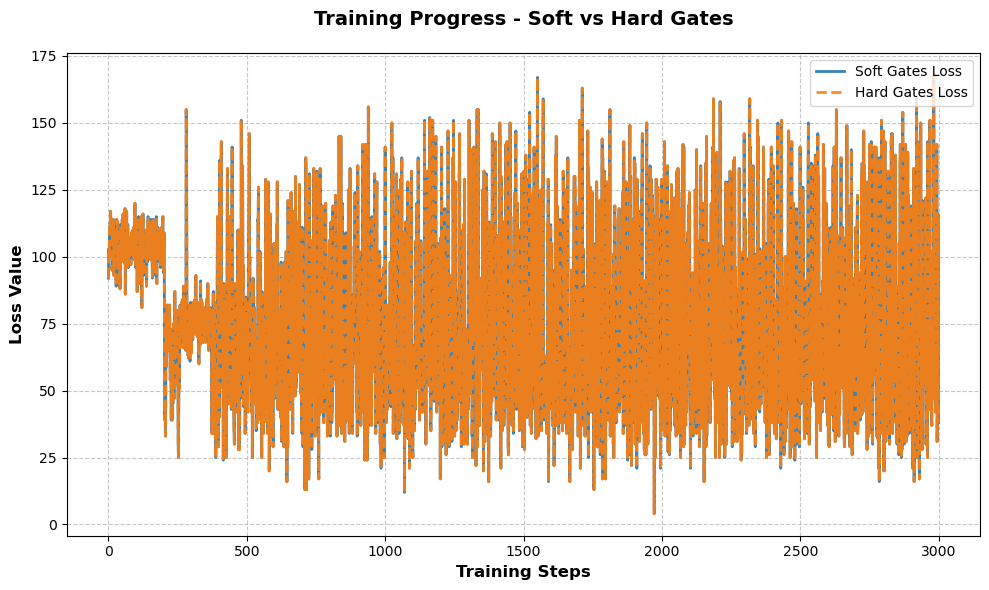

In [14]:
#Game of life
jax.clear_caches()
N = 128

hyperparams_life = {'perceive': {}, 'update': {}}
hyperparams_life['seed'] = 23
hyperparams_life['lr'] = 0.05
hyperparams_life['batch_size'] = 20
hyperparams_life['num_epochs'] = 3000
hyperparams_life['num_steps'] = 1
hyperparams_life['channels'] = 1
hyperparams_life['perceive']['n_kernels'] = 16
hyperparams_life['perceive']['layers'] = [9, 8, 4, 2, 1]
hyperparams_life['perceive']['connections'] = ['first_kernel', 'unique', 'unique', 'unique',]
init_life = (hyperparams_life['perceive']['n_kernels'] * hyperparams_life['channels'] * hyperparams_life['perceive']['layers'][-1] + hyperparams_life['channels'])
hyperparams_life['update']['layers'] = ([init_life] + [128] * 16 + [128, 64, 32, 16, 8, 4, 2, hyperparams_life['channels']])
hyperparams_life['update']['connections'] = ['unique'] * len(hyperparams_life['update']['layers'])
hyperparams_life['async_training'] = False
hyperparams_life['training'] = False
hyperparams_life['periodic'] = True


hyperparams_life.update({
    # 'dataset': 'cifar-10-3-thresholds',
    'seed': 0,
    # 'channels': 8,
    # 'batch_size': 128,
    # 'valid_set_size': 0.1,
    # 'num_workers': 0,
    # 'num_steps': 1200,
    # 'eval_every': 100,
    'learning_rate': 0.03,
    'weight_decay': 1e-4,
    'clip_value': 100.0,
    # 'connections': 'random',
    'logic_family': 'light',  # 'full' or 'light'
    'architecture': 'light_st',  # full: plain softmax / gumbel ST / dirichlet(softplus(logits)); light: 'light_st' (recommended) or 'light_sigmoid'
    'gumb_tau': 1.0,
    'dirichlet_concentration': 12.0,
    'sum_tau': 10.0,
    # 'num_neurons': 8,
    # 'num_layers': 3,
    # 'toy_num_bits': 6,
    # 'data_roots': {
    #     'block': './blocks_dataset',
    #     'uci': './data-uci',
    #     'mnist': './data-mnist',
    #     'cifar': './data-cifar',
    # },
})

train_state, wires, apply_fn, optimizer = dlca_init_state(hyperparams_life)
train_step = make_dlca_train_step(apply_fn, optimizer, loss_fn=dlca_loss_f)


@partial(jax.jit, static_argnums=(1,))
def simulate_batch(boards, steps):
  def simulate_one(board):
    states = [board]
    for _ in range(steps):
      board = step(board)
      states.append(board)
    return jnp.stack(states)

  return jax.vmap(simulate_one)(boards)

def generate_binary_tensor():
  # Generate all possible combinations of 0s and 1s for 9 positions
  binary_numbers = jnp.arange(512)
  # Convert to binary and pad to 9 bits
  binary_array = (
      (binary_numbers[:, None] & (1 << jnp.arange(8, -1, -1))) > 0
  ).astype(jnp.float32)
  # Reshape to (512, 9, 1)
  tensor = binary_array.reshape(512, 9, 1)
  return tensor

initial_boards = generate_binary_tensor().reshape(-1, 3, 3).astype(jnp.uint8)

def sample_batch(key, trajectories, batch_size, state_size):
  n_samples = trajectories.shape[0]
  sample_idx = jax.random.randint(
      key, minval=0, maxval=n_samples, shape=(batch_size,)
  )
  init = jnp.zeros(
      (*trajectories[sample_idx, 0].shape, state_size), dtype=jnp.float32
  )
  init = init.at[..., 0].set(trajectories[sample_idx, 0])
  return init, trajectories[sample_idx, 1:, ..., None].astype(jnp.float32)

key = random.PRNGKey(hyperparams_life['seed'])
key, subkey = random.split(key, 2)

trajectories = simulate_batch(initial_boards, hyperparams_life['num_steps'])
batch_input, batch_output = sample_batch(
    subkey, trajectories, hyperparams_life['batch_size'], hyperparams_life['channels']
)



print(batch_input[8].reshape(3, 3))
print(batch_output[8, 0, :, :].reshape(3, 3))

ii = get_grid_patches(batch_input[8], 3, 1, 1)
print(ii[0].reshape(3, 3))


loss_soft = []
loss_hard = []

for i in range(hyperparams_life['num_epochs']):
    key, sample_key = random.split(train_state.key, 2)
    train_x, train_y = sample_batch(
        sample_key,
        trajectories,
        hyperparams_life['batch_size'],
        hyperparams_life['channels'],
    )
    train_state, soft_loss, hard_loss = train_step(
        train_state,
        train_x,
        train_y[:, 0, :, :],
        wires,
        hyperparams_life['periodic'],
        hyperparams_life['num_steps'],
        hyperparams_life['async_training'],
    )
    diag = inspect_dlca_training_batch(
        train_state,
        train_x,
        train_y[:, 0, :, :],
        wires,
        apply_fn,
        hyperparams_life['periodic'],
        hyperparams_life['num_steps'],
        hyperparams_life['async_training'],
        optimizer=optimizer,
        loss_fn=dlca_loss_f,
    )
    diag
    loss_soft.append(soft_loss)
    loss_hard.append(hard_loss['hard'])

    if i % 100 == 0:
        clear_output(wait=True)
        plot_training_progress(loss_soft, loss_hard, 1)
        print(i, soft_loss, hard_loss['hard'])

clear_output(wait=True)
plot_training_progress(loss_soft, loss_hard, 1, 'gof_loss.svg')
#train_state, wires, apply_fn, optimizer
# # train_x, train_y = sample_batch(sample_key,trajectories,hyperparams['batch_size'],hyperparams['channels'],)
# # train_x, train_y = sample_batch(sample_key,trajectories,hyperparams['batch_size'],hyperparams['channels'],)

In [15]:
print (diag)

{'active_path': 'dlca_cell9_make_train_step', 'loss_reduction': 'sum', 'train_x_shape': (20, 3, 3, 1), 'train_y_shape': (20, 3, 3, 1), 'y_soft_shape': (20, 3, 3, 1), 'y_hard_shape': (20, 3, 3, 1), 'train_x_dtype': 'float32', 'train_y_dtype': 'float32', 'y_soft_dtype': 'float32', 'y_hard_dtype': 'float32', 'loss_shape': (), 'hard_shape': (), 'loss_scalar': True, 'hard_scalar': True, 'soft_loss_sum': 38.0, 'hard_loss_sum': 38.0, 'soft_loss_mean': 0.21111111342906952, 'hard_loss_mean': 0.21111111342906952, 'element_count': 180, 'grads_finite': True, 'params_finite': True, 'grad_l2': 16.43114471435547, 'same_rng_root_for_soft_and_hard': True, 'updates_finite': True, 'update_l2': 0.4881567358970642}
